# RFM Analysis
This notebook calculates customer-level recency, frequency, and monetary values and adds quartile-based RFM scores.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
from src.rfm import calculate_rfm, score_rfm

clean_path = ROOT / 'data' / 'cleaned' / 'ecommerce_transactions_cleaned.csv'
df = pd.read_csv(clean_path, parse_dates=['Order Date'])
rfm = score_rfm(calculate_rfm(df))
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Last_Order_Date,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,CUST-0424,24,18,3908.47,2024-12-08,4,4,4,444,12
1,CUST-0390,41,16,2879.98,2024-11-21,4,4,4,444,12
2,CUST-0069,16,18,2860.53,2024-12-16,4,4,4,444,12
3,CUST-0826,24,16,2701.81,2024-12-08,4,4,4,444,12
4,CUST-0659,27,16,2675.58,2024-12-05,4,4,4,444,12


In [2]:
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2)

,Recency,Frequency,Monetary
count,807.00,807.00,807.00
mean,186.10,4.46,658.82
std,173.79,3.04,516.76
min,1.00,1.00,28.59
25%,46.50,2.00,264.35
50%,126.00,4.00,514.99
75%,287.50,6.00,925.46
max,729.00,18.00,3908.47


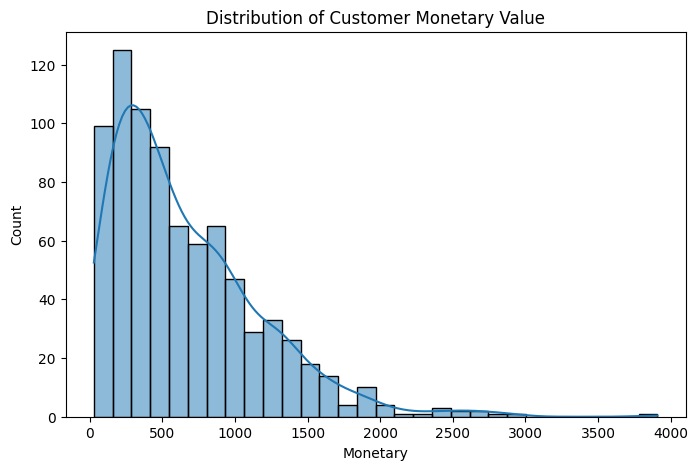

In [3]:
plt.figure(figsize=(8, 5))
sns.histplot(rfm['Monetary'], bins=30, kde=True)
plt.title('Distribution of Customer Monetary Value')
plt.show()

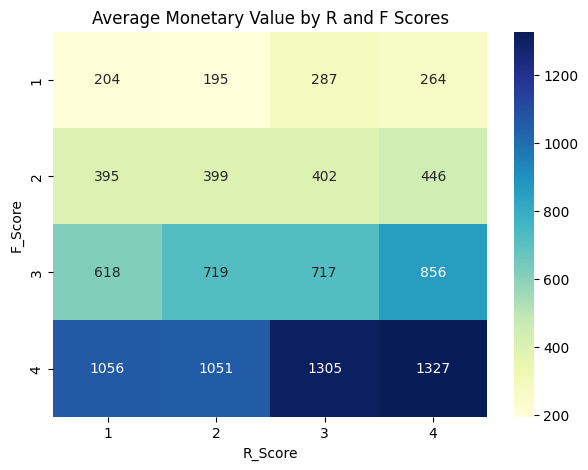

In [4]:
pivot = rfm.pivot_table(index='F_Score', columns='R_Score', values='Monetary', aggfunc='mean')
plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Average Monetary Value by R and F Scores')
plt.show()

In [5]:
rfm_path = ROOT / 'data' / 'cleaned' / 'customer_rfm_scores.csv'
rfm.to_csv(rfm_path, index=False)
rfm_path

WindowsPath('C:/Users/asus/OneDrive/Documents/customer-segmentation-rfm-analysis/data/cleaned/customer_rfm_scores.csv')